In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("insurance_pre.csv")
dataset.head()

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520


In [3]:
# Exploratory Data Analysis

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# First 5 records
dataset.head()

# Shape
dataset.shape

# Information
dataset.info()

# Statistical Summary
dataset.describe()

# Missing Values
dataset.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 62.8+ KB


age         0
sex         0
bmi         0
children    0
smoker      0
charges     0
dtype: int64

The dataset consists of 1338 rows and 6 columns before preprocessing.

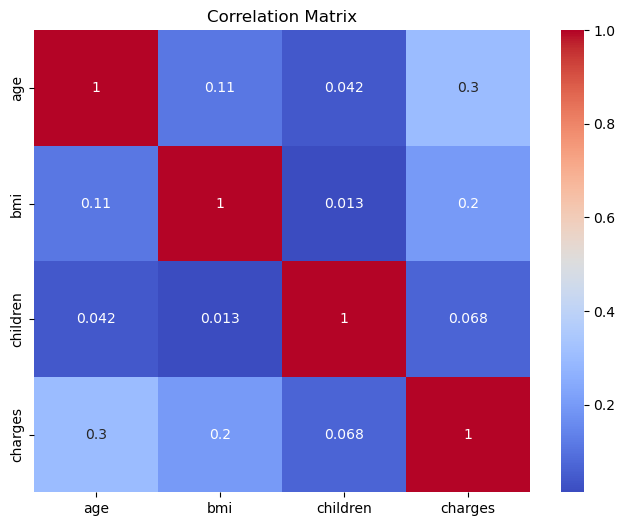

In [5]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(dataset.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

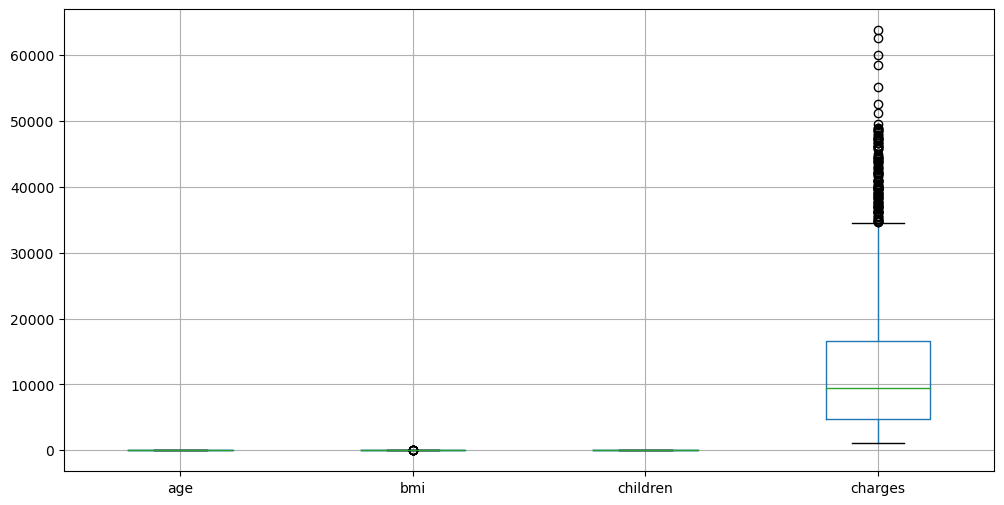

In [6]:
# Box Plot
plt.figure(figsize=(12,6))
dataset.boxplot()
plt.show()

In [7]:
# Data Preprocessing - One hot encoding

In [8]:
dataset=pd.get_dummies(dataset,drop_first=True)
dataset.head()

,age,bmi,children,charges,sex_male,smoker_yes
0,19,27.900,0,16884.92400,0,1
1,18,33.770,1,1725.55230,1,0
2,28,33.000,3,4449.46200,1,0
3,33,22.705,0,21984.47061,1,0
4,32,28.880,0,3866.85520,1,0


After one-hot encoding, the categorical variables (sex and smoker) were converted into numerical variables (sex_male and smoker_yes) suitable for machine learning algorithms.

In [9]:
dataset.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes'], dtype='object')

In [10]:
independent=dataset[['age', 'bmi', 'children', 'sex_male', 'smoker_yes']]
dependent=dataset['charges']

The dataset was split into 70% training data and 30% testing data using train_test_split(random_state=0)

In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(independent, dependent, test_size=0.30, random_state=0)

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
# Baseline Model
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_predict_lr=lr.predict(x_test)
lr_r2=r2_score(y_test,y_predict_lr)
print("Linear Regression R2 score:",lr_r2)

# Hyperparameter Grid
param_grid = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

# Grid Search
grid_lr = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

grid_lr.fit(x_train, y_train)

print("Best Parameters:", grid_lr.best_params_)
print("Best CV Score:", grid_lr.best_score_)

# Tuned Model Evaluation
best_lr = grid_lr.best_estimator_

y_pred_best_lr = best_lr.predict(x_test)

best_lr_r2 = r2_score(y_test, y_pred_best_lr)

print("Tuned Linear Regression R2 Score:", best_lr_r2)

Linear Regression R2 score: 0.7894790349867009
Best Parameters: {'fit_intercept': True, 'positive': True}
Best CV Score: 0.7224052800517811
Tuned Linear Regression R2 Score: 0.7894429387120753


In [13]:
# Baseline Model
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor(random_state=0)
dt.fit(x_train,y_train)
y_predict_dt=dt.predict(x_test)
dt_r2=r2_score(y_test,y_predict_dt)
print("Decision Tree R2 score:",dt_r2)

# Hyperparameter Grid
param_grid = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
    'splitter': ['best', 'random'],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


# Grid Search
grid_dt = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=0),
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

grid_dt.fit(x_train, y_train)

print("Best Parameters:", grid_dt.best_params_)
print("Best CV Score:", grid_dt.best_score_)

# Tuned Model Evaluation
best_dt = grid_dt.best_estimator_

y_pred_best_dt = best_dt.predict(x_test)

best_dt_r2 = r2_score(y_test, y_pred_best_dt)

print("Tuned Decision Tree R2 Score:", best_dt_r2)

Decision Tree R2 score: 0.6957219144244762
Best Parameters: {'criterion': 'absolute_error', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'splitter': 'best'}
Best CV Score: 0.8383371883594133
Tuned Decision Tree R2 Score: 0.8860958934822316


In [14]:
# Baseline Model
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(random_state=0)

rf.fit(x_train,y_train)
y_predict_rf=rf.predict(x_test)
rf_r2=r2_score(y_test,y_predict_rf)
print("Random Forest R2 score:", rf_r2)

# Hyperparameter Grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Grid Search
grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=0),
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

grid_rf.fit(x_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)

# Tuned Model Evaluation
best_rf = grid_rf.best_estimator_

y_pred_best_rf = best_rf.predict(x_test)

best_rf_r2 = r2_score(y_test, y_pred_best_rf)

print("Tuned Random Forest R2 score:", best_rf_r2)

Random Forest R2 score: 0.8538307913484513
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Best CV Score: 0.8276819717517399
Tuned Random Forest R2 score: 0.8823900127526229


In [15]:
# Baseline Model
from sklearn.ensemble import GradientBoostingRegressor
gb=GradientBoostingRegressor(random_state=0)

gb.fit(x_train,y_train)
y_predict_gb=gb.predict(x_test)
gb_r2=r2_score(y_test,y_predict_gb)
print("Gradient Boosting R2 score:", gb_r2)

# Hyperparameter Grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.8, 1.0]
}

# Grid Search
grid_gb = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=0),
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

grid_gb.fit(x_train, y_train)

print("Best Parameters:", grid_gb.best_params_)
print("Best CV Score:", grid_gb.best_score_)

# Tuned Model Evaluation
best_gb = grid_gb.best_estimator_

y_pred_best_gb = best_gb.predict(x_test)

best_gb_r2 = r2_score(y_test, y_pred_best_gb)

print("Tuned Gradient Boosting R2 score:", best_gb_r2)

Gradient Boosting R2 score: 0.8833974199848822
Best Parameters: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 150, 'subsample': 0.8}
Best CV Score: 0.8415104596116347
Tuned Gradient Boosting R2 score: 0.8918059871572992


In [16]:
# Baseline model
from sklearn.ensemble import ExtraTreesRegressor
et=ExtraTreesRegressor(random_state=0)

et.fit(x_train,y_train)
y_pred_et=et.predict(x_test)
et_r2=r2_score(y_test,y_pred_et)
print("Extra Trees R2 score:", et_r2)

# Hyperparameter Grid
et_param_grid = {
    'n_estimators': [50, 100, 200],
    'criterion': ['squared_error', 'absolute_error'],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Grid Search
grid_et = GridSearchCV(
    estimator=ExtraTreesRegressor(random_state=0),
    param_grid=et_param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

grid_et.fit(x_train, y_train)
print("Best Parameters:", grid_et.best_params_)
print("Best CV Score:", grid_et.best_score_)

# Tuned Model Evaluation
best_et = grid_et.best_estimator_

y_pred_best_et = best_et.predict(x_test)

best_et_r2 = r2_score(y_test, y_pred_best_et)

print("Tuned Extra Trees R2 Score:", best_et_r2)

Extra Trees R2 score: 0.8294037634295655
Best Parameters: {'criterion': 'absolute_error', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Score: 0.8189195981338676
Tuned Extra Trees R2 Score: 0.878342874372208


In [17]:
# Final Model Comparison

In [18]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Extra Trees"
    ],
    "Baseline R2": [
        lr_r2,
        dt_r2,
        rf_r2,
        gb_r2,
        et_r2
    ],
    "Tuned R2": [
        best_lr_r2,
        best_dt_r2,
        best_rf_r2,
        best_gb_r2,
        best_et_r2
    ]
})

results = results.sort_values(by="Tuned R2", ascending=False)

print(results)

               Model  Baseline R2  Tuned R2
3  Gradient Boosting     0.883397  0.891806
1      Decision Tree     0.695722  0.886096
2      Random Forest     0.853831  0.882390
4        Extra Trees     0.829404  0.878343
0  Linear Regression     0.789479  0.789443


In [19]:
# Feature Importance of Best Model

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Create Feature Importance DataFrame
feature_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': best_gb.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

      Feature  Importance
4  smoker_yes    0.681967
1         bmi    0.179791
0         age    0.128415
2    children    0.009580
3    sex_male    0.000247


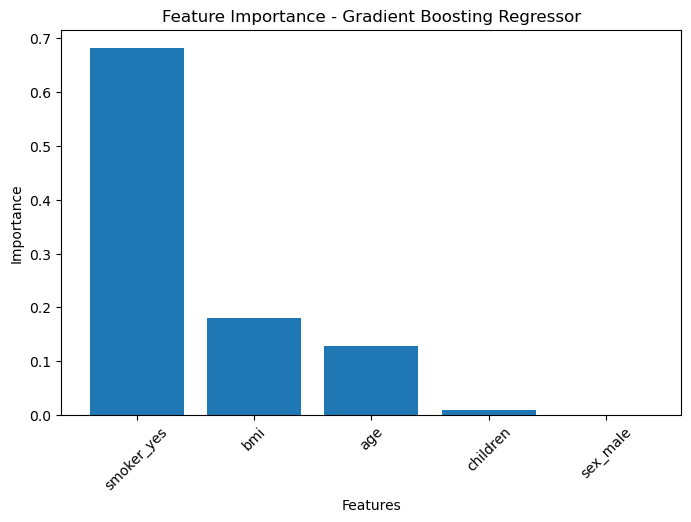

In [21]:
plt.figure(figsize=(8,5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
    
)

plt.title("Feature Importance - Gradient Boosting Regressor")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)

plt.show()

The feature importance analysis of the Gradient Boosting Regressor indicates the relative contribution of each independent variable in predicting insurance charges. Features with higher importance values have a greater influence on the model's predictions.

From the feature importance plot, it is observed that "smoker_yes" has the most influential features contribute significantly to the prediction of medical insurance charges, while features with lower importance have a comparatively smaller impact.